In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holidays
pd.set_option('display.max_rows', None)

In [51]:
df_interval = pd.read_csv('./data/A - Interval.csv', index_col=0)
df_interval.head()

,Month,Day,Interval,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT
0,April,1,00:00:00,1.0,5.0,0.0,0.0,137.60
1,April,1,00:30:00,1.0,5.0,0.0,0.0,263.40
2,April,1,01:00:00,1.0,4.0,0.0,0.0,333.25
3,April,1,01:30:00,1.0,3.0,0.0,0.0,170.00
4,April,1,02:00:00,1.0,1.0,0.0,0.0,667.00


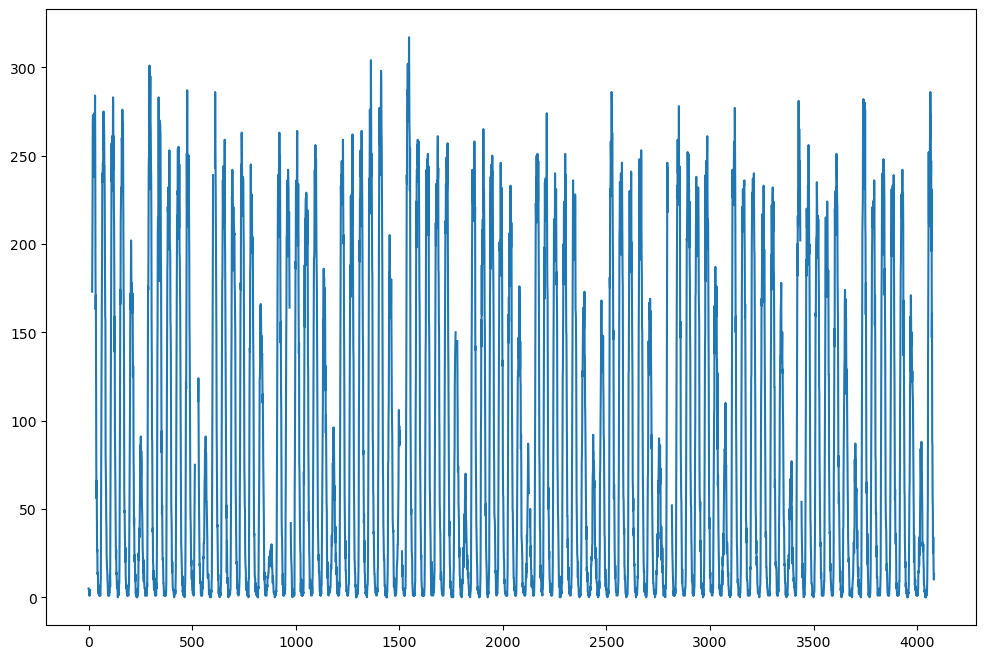

In [52]:
plt.figure(figsize=(12, 8))
plt.plot(df_interval['Call Volume'])
plt.show()


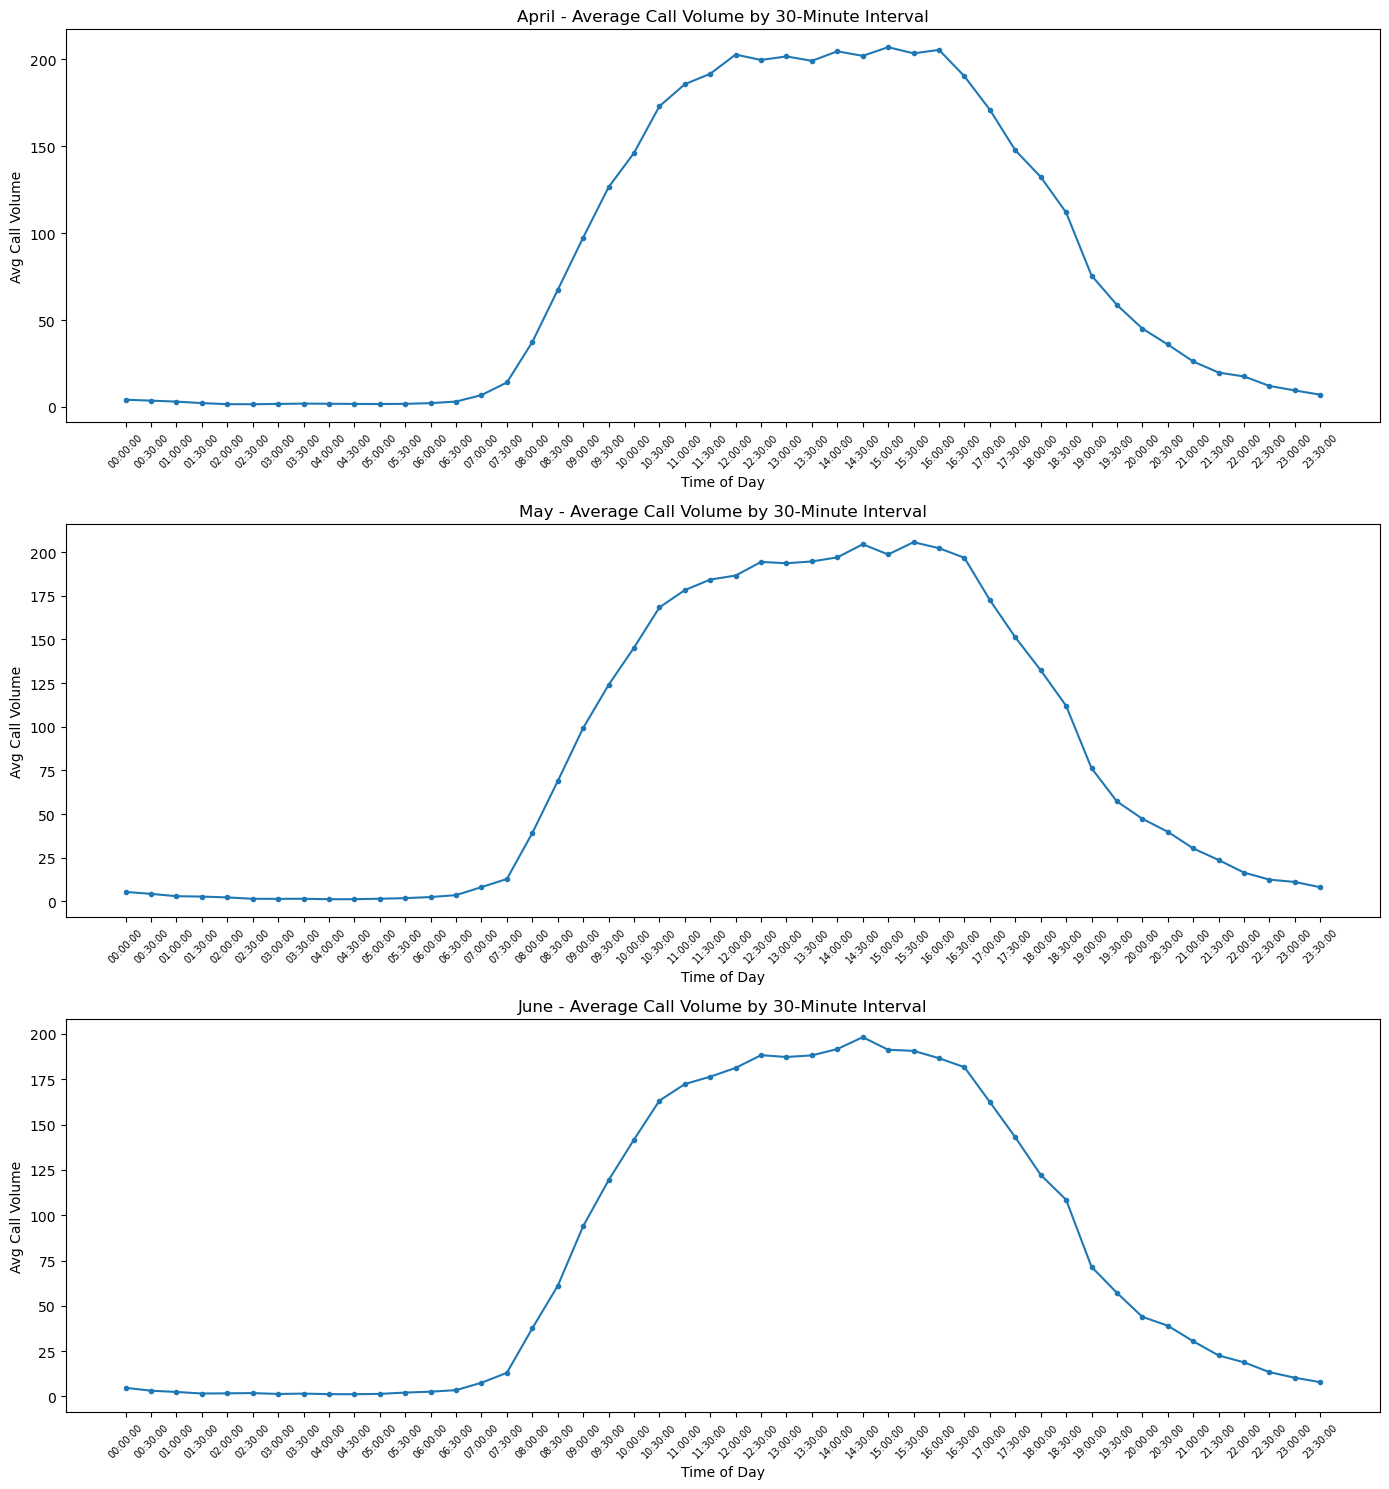

In [53]:
months = ['April', 'May', 'June']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, month in zip(axes, months):
    df_month = df_interval[df_interval['Month'] == month]
    interval_volume = df_month.groupby('Interval')['Call Volume'].mean().reset_index()
    
    ax.plot(interval_volume['Interval'], interval_volume['Call Volume'], marker='o', linewidth=1.5, markersize=3)
    ax.set_title(f'{month} - Average Call Volume by 30-Minute Interval')
    ax.set_xlabel('Time of Day')
    ax.set_ylabel('Avg Call Volume')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

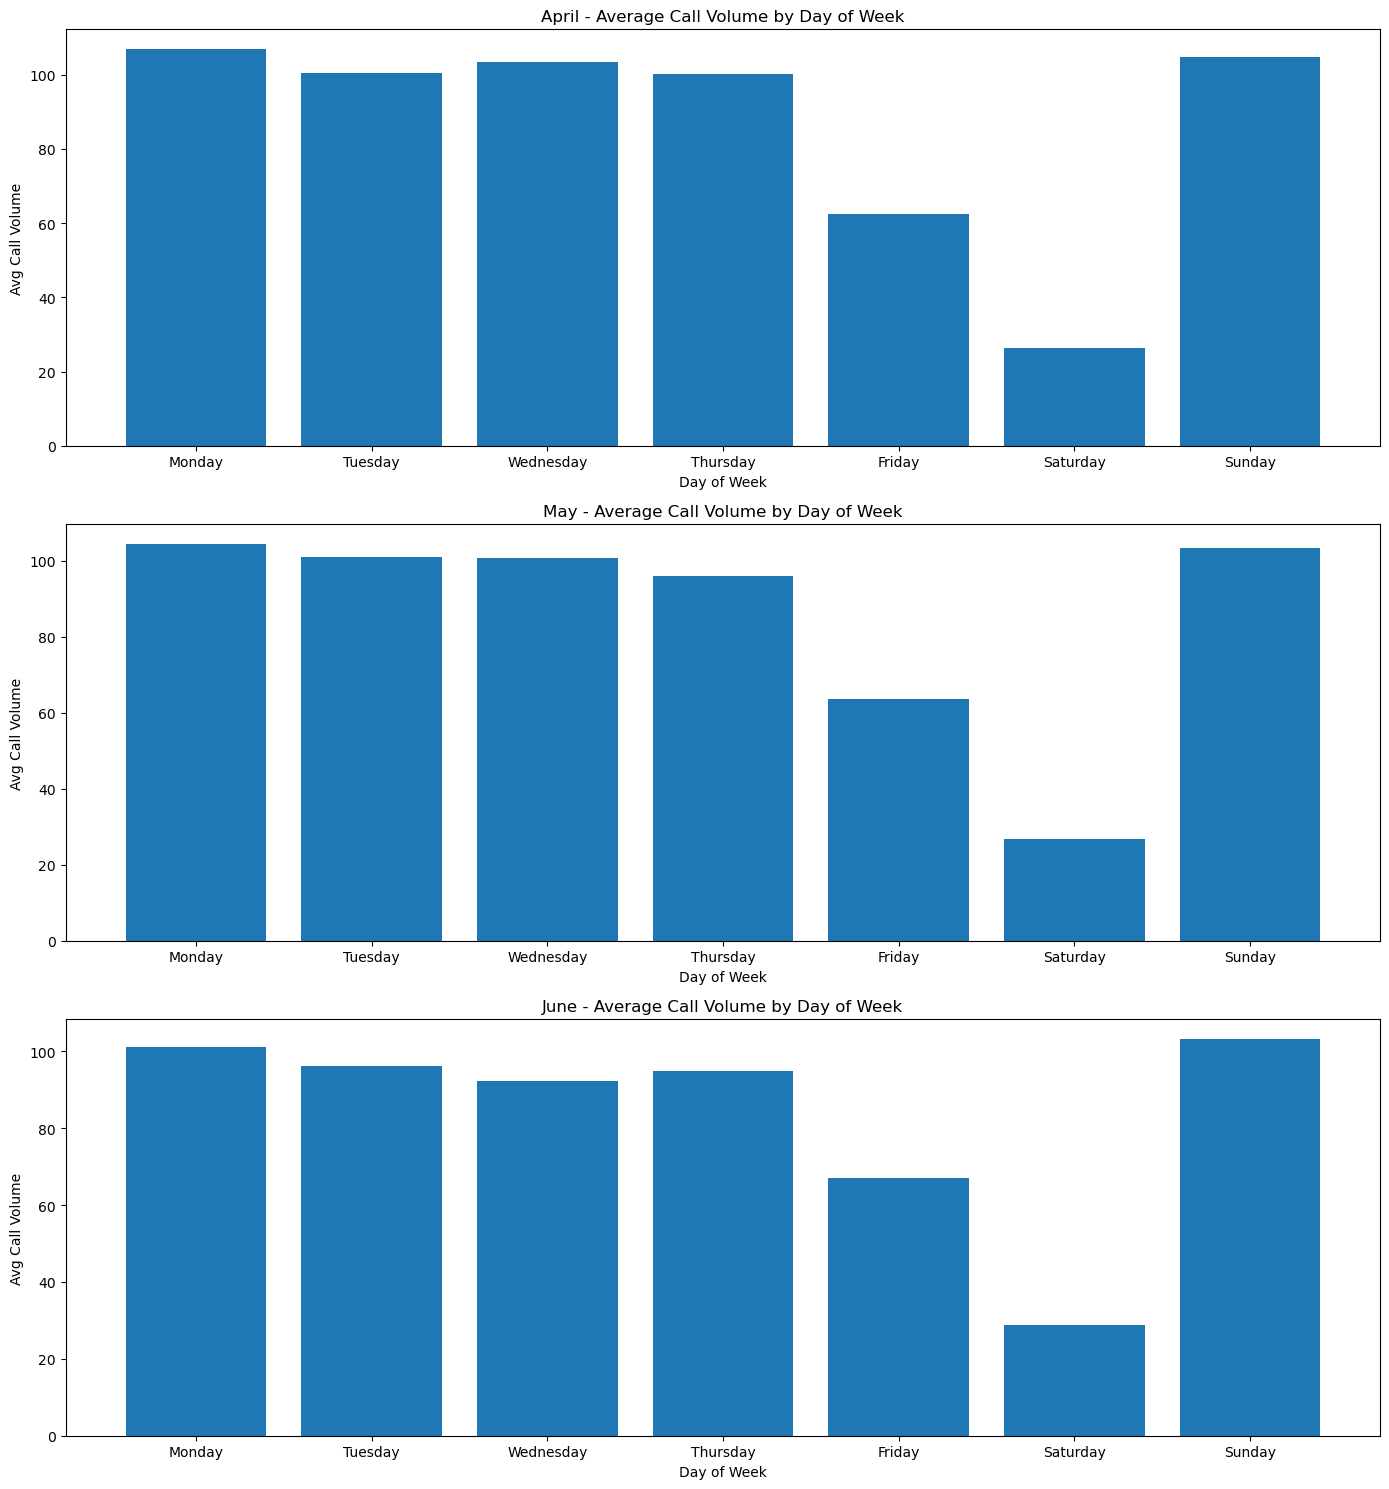

In [54]:
df_interval['Date'] = pd.to_datetime(df_interval['Month'] + ' ' + df_interval['Day'].astype(str) + ' 2024')
df_interval['DayOfWeek'] = df_interval['Date'].dt.day_name()

# Define order so it plots Mon -> Sun
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

months = ['April', 'May', 'June']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, month in zip(axes, months):
    df_month = df_interval[df_interval['Month'] == month]
    day_volume = df_month.groupby('DayOfWeek')['Call Volume'].mean().reindex(day_order)
    
    ax.bar(day_volume.index, day_volume.values)
    ax.set_title(f'{month} - Average Call Volume by Day of Week')
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Avg Call Volume')

plt.tight_layout()
plt.show()


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

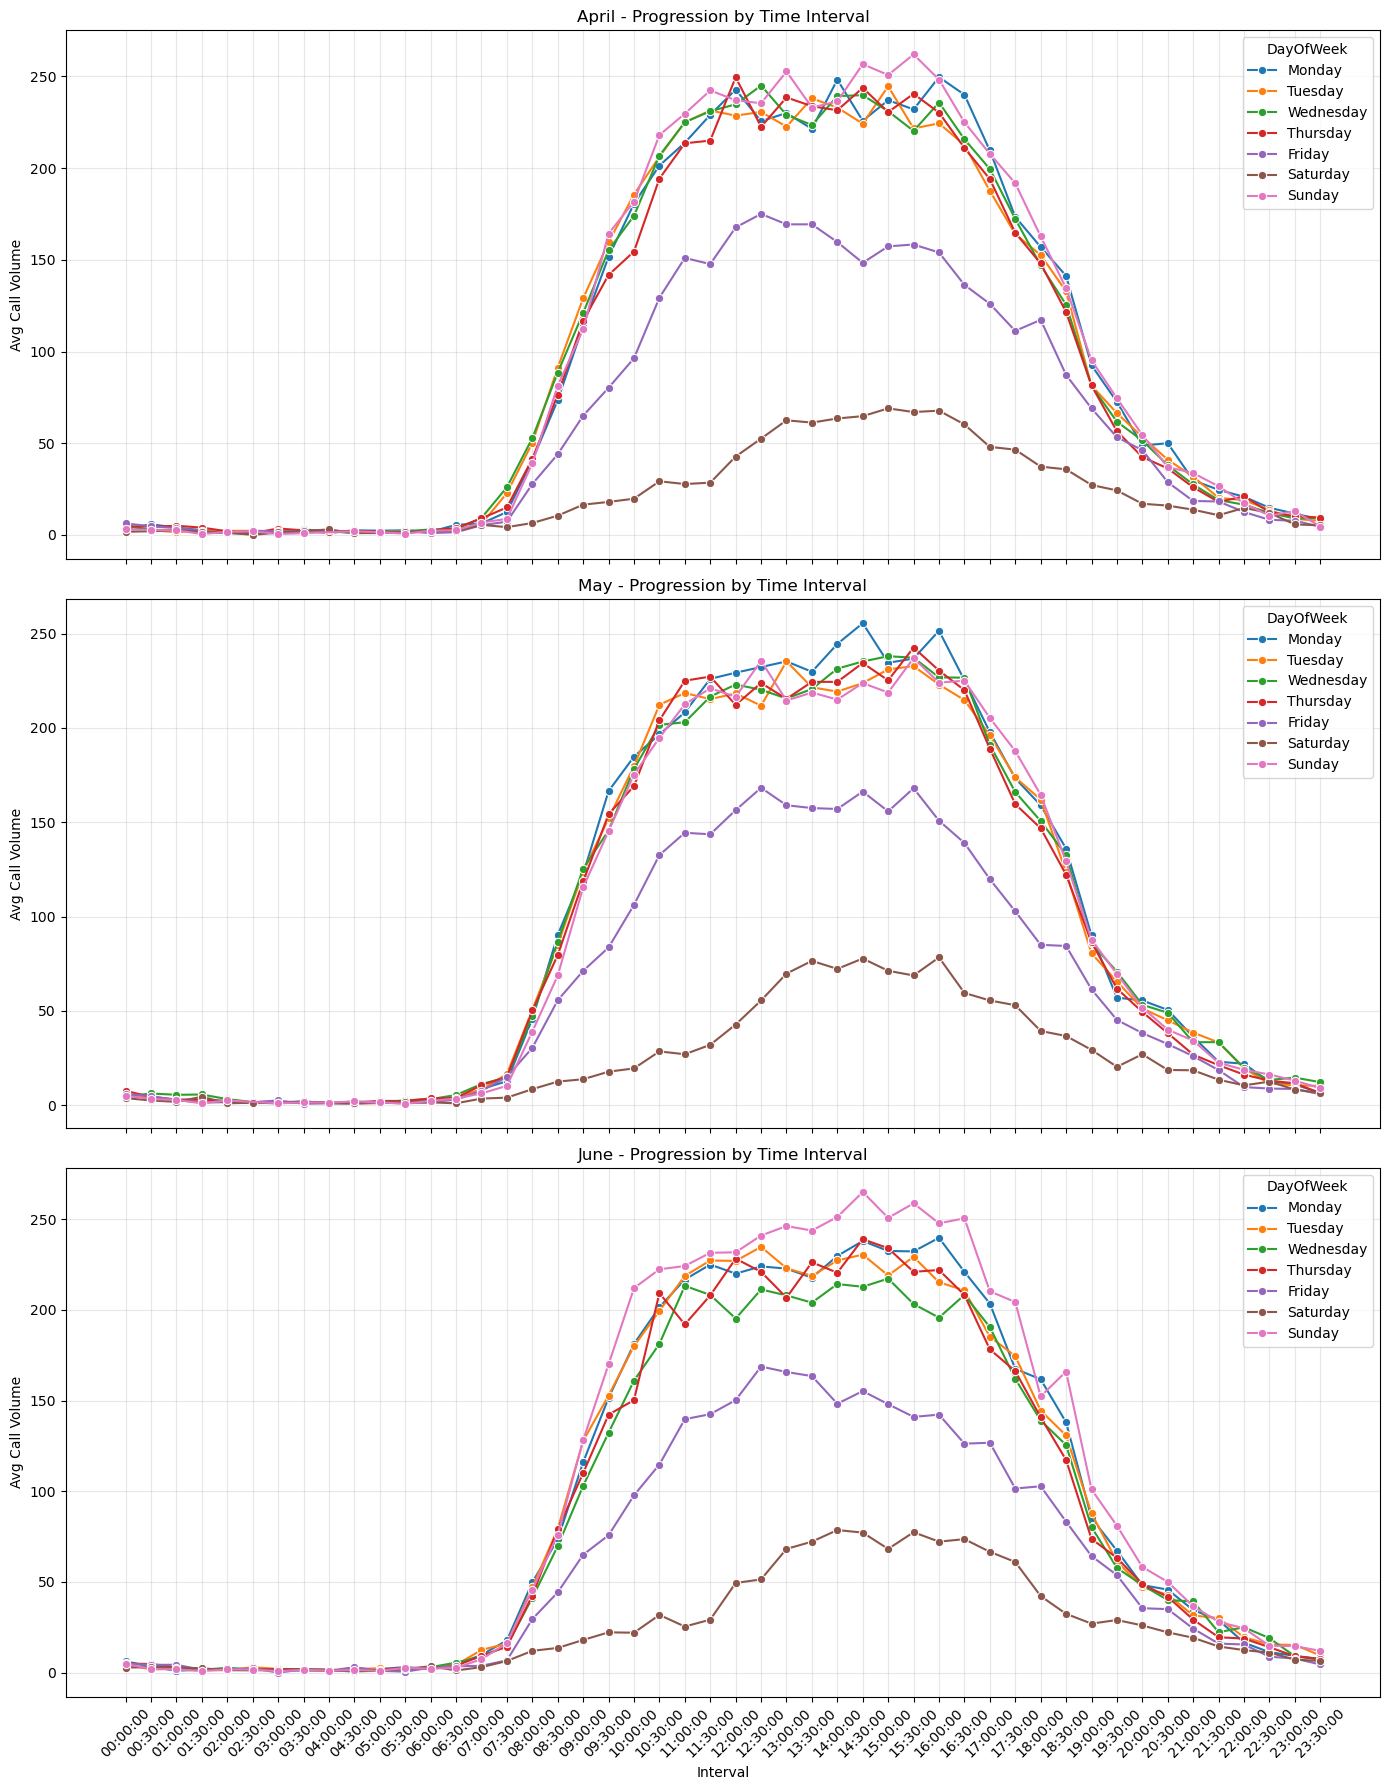

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ... (your existing date/day setup code) ...

# 1. Ensure Intervals are sorted chronologically
# If your interval column is a string, you might want to convert it to a sortable time
df_interval = df_interval.sort_values(by=['Date', 'Interval'])

months = ['April', 'May', 'June']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

for ax, month in zip(axes, months):
    # Filter for the specific month
    df_month = df_interval[df_interval['Month'] == month]
    
    # 2. Group by Day and Interval to get the average for each specific time slot
    # This keeps the 'Interval' as a column for the X-axis
    interval_data = df_month.groupby(['DayOfWeek', 'Interval'])['Call Volume'].mean().reset_index()
    
    # 3. Use Seaborn to plot multiple lines (one per DayOfWeek)
    sns.lineplot(
        data=interval_data, 
        x='Interval', 
        y='Call Volume', 
        hue='DayOfWeek', 
        hue_order=day_order,
        ax=ax,
        marker='o' # Adds dots to each interval point
    )
    
    ax.set_title(f'{month} - Progression by Time Interval')
    ax.set_ylabel('Avg Call Volume')
    ax.grid(True, alpha=0.3)
    
    # Rotate x-labels if you have many intervals (like 15-min or 30-min)
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

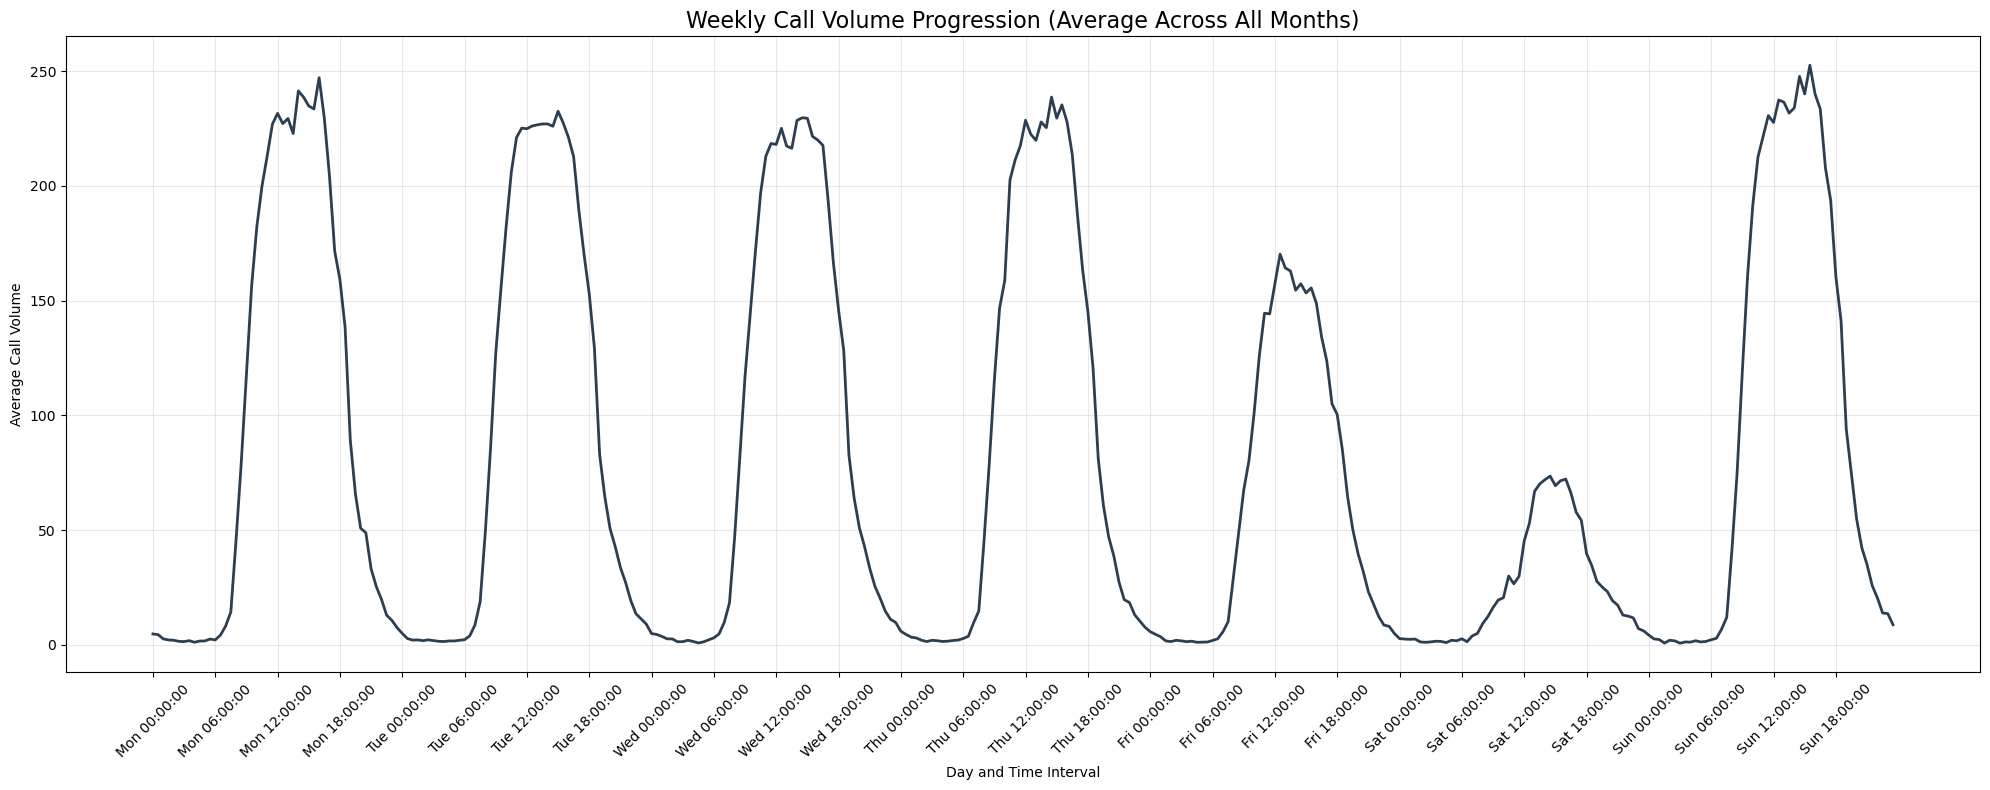

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a numeric mapping for sorting days correctly
day_map = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
}
df_interval['DayNum'] = df_interval['DayOfWeek'].map(day_map)

# 2. Aggregate across all months
# We group by DayNum (for sorting) and Interval to get the average volume
df_agg = df_interval.groupby(['DayNum', 'DayOfWeek', 'Interval'])['Call Volume'].mean().reset_index()

# 3. Sort by DayNum then Interval to ensure the line flows Mon -> Sun
df_agg = df_agg.sort_values(['DayNum', 'Interval'])

# 4. Create a label for the X-axis that combines Day and Time
df_agg['Timeline'] = df_agg['DayOfWeek'].str[:3] + " " + df_agg['Interval'].astype(str)

# Plotting
plt.figure(figsize=(20, 8))
sns.lineplot(data=df_agg, x='Timeline', y='Call Volume', sort=False, color='#2c3e50', linewidth=2)

# Cleanup X-Axis (Too many labels will overlap, so we show every Nth label)
ax = plt.gca()
ticks = ax.get_xticks()
labels = ax.get_xticklabels()
# Show a label every 12 intervals (e.g., every 6 hours if intervals are 30 mins)
plt.xticks(ticks[::12], [l.get_text() for l in labels[::12]], rotation=45)

plt.title('Weekly Call Volume Progression (Average Across All Months)', fontsize=16)
plt.xlabel('Day and Time Interval')
plt.ylabel('Average Call Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
import pandas as pd
import numpy as np
from itertools import product

def load_and_clean_interval(filepath, portfolio_name):
    df = pd.read_csv(filepath)
    
    # ── 1. Standardize column names ──────────────────────────────────────────
    df.columns = df.columns.str.strip()
    
    # ── 2. Parse Service Level as float (may come in as "99.49%" or 0.9949) ──
    if df['Service Level'].dtype == object:
        df['Service Level'] = df['Service Level'].str.replace('%', '').astype(float) / 100
    
    # ── 3. Parse Abandoned Rate similarly ────────────────────────────────────
    if df['Abandoned Rate'].dtype == object:
        df['Abandoned Rate'] = df['Abandoned Rate'].str.replace('%', '').astype(float) / 100

    # ── 4. Build skeleton using ONLY valid days per month ────────────────────
    month_map = {
        'January':1,'February':2,'March':3,'April':4,
        'May':5,'June':6,'July':7,'August':8,
        'September':9,'October':10,'November':11,'December':12
    }

    all_intervals = [f"{h:02d}:{m:02d}:00" for h, m in product(range(24), [0, 30])]
    
    # Get actual (Month, Day) combos that exist in the data — avoids April 31 etc.
    valid_month_days = df[['Month', 'Day']].drop_duplicates()

    skeleton = pd.DataFrame(
        [(row.Month, row.Day, interval)
         for _, row in valid_month_days.iterrows()
         for interval in all_intervals],
        columns=['Month', 'Day', 'Interval']
    )

    df = skeleton.merge(df, on=['Month', 'Day', 'Interval'], how='left')
    
    # ── 5. Add date + time features ──────────────────────────────────────────
    df['Month_Num'] = df['Month'].map(month_map)
    df['Date']      = pd.to_datetime(
        df['Month_Num'].astype(str) + '-' + df['Day'].astype(str) + '-2024',
        format='%m-%d-%Y'
    )
    df['DayOfWeek']   = df['Date'].dt.day_name()
    df['DayOfWeek_N'] = df['Date'].dt.dayofweek        # 0=Mon, 6=Sun
    df['WeekOfMonth'] = (df['Day'] - 1) // 7 + 1
    df['IntervalIdx'] = df['Interval'].apply(
        lambda x: int(x.split(':')[0]) * 2 + int(x.split(':')[1]) // 30
    )  # 0–47
    df['Hour']       = df['Interval'].apply(lambda x: int(x.split(':')[0]))
    df['Is_Weekend'] = df['DayOfWeek_N'].isin([5, 6]).astype(int)
    df['Portfolio']  = portfolio_name

    # ── 6. Smart missing value imputation ────────────────────────────────────
    df = df.sort_values(['Month', 'Day', 'IntervalIdx']).reset_index(drop=True)

    # Overnight slots (midnight–4am): zero-fill call volume
    overnight_mask = df['IntervalIdx'].between(0, 7)
    df.loc[overnight_mask & df['Call Volume'].isna(), 'Call Volume'] = 0

    # Linear interpolation within each day, then fill edges
    for col in ['Call Volume', 'CCT', 'Abandoned Calls', 'Abandoned Rate', 'Service Level']:
        df[col] = (
            df.groupby(['Month', 'Day'])[col]
              .transform(lambda x: x.interpolate(method='linear').bfill().ffill())
        )

    # Fallback: same weekday + same interval median
    for col in ['CCT', 'Call Volume', 'Abandoned Calls', 'Abandoned Rate', 'Service Level']:
        df[col] = df.groupby(['DayOfWeek_N', 'IntervalIdx'])[col]\
                    .transform(lambda x: x.fillna(x.median()))

    # ── 7. Enforce non-negativity & valid ranges ──────────────────────────────
    for col in ['Call Volume', 'CCT', 'Abandoned Calls', 'Abandoned Rate']:
        df[col] = df[col].clip(lower=0)
    df['Abandoned Rate'] = df['Abandoned Rate'].clip(0, 1)

    # ── 8. Round volume & abandoned calls to integers ─────────────────────────
    df['Call Volume']     = df['Call Volume'].round().astype(int)
    df['Abandoned Calls'] = df['Abandoned Calls'].round().astype(int)

    return df


# ── Load all 4 portfolios ─────────────────────────────────────────────────────
portfolios = {
    'A': './data/A - Interval.csv',
    'C': './data/C - Interval.csv',
}

cleaned = {}
for name, path in portfolios.items():
    cleaned[name] = load_and_clean_interval(path, name)
    print(f"Portfolio {name}: {len(cleaned[name])} rows, "
          f"{cleaned[name].isna().sum().sum()} NaNs remaining")

df_all = pd.concat(cleaned.values(), ignore_index=True)
print(f"\nMaster dataframe: {df_all.shape}")


Portfolio A: 4368 rows, 292 NaNs remaining
Portfolio C: 4368 rows, 9 NaNs remaining

Master dataframe: (8736, 18)


## New

In [59]:
import pandas as pd
import numpy as np

df_interval = pd.read_csv('./data/A - Interval.csv', index_col=0)


# 1. Define the start and end of the period
# April 1st, 2025 at 00:00 to June 30th, 2025 at 23:30
start = '2025-04-01 00:00:00'
end = '2025-06-30 23:30:00'

# 2. Generate the date range with 30-minute frequency
# 30min or 30T is the frequency for 30-minute increments
dr = pd.date_range(start=start, end=end, freq='30min')

# 3. Create the DataFrame and extract the requested columns
df = pd.DataFrame({'Timestamp': dr})

df_intervals = pd.DataFrame({
    'Month': df['Timestamp'].dt.month_name(),
    'Day': df['Timestamp'].dt.day,
    'Interval': df['Timestamp'].dt.strftime('%H:%M:%S'),
    'Day of the Week': df['Timestamp'].dt.day_name()
})

df = df_intervals.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')
df['Call Volume'] = df['Call Volume'].interpolate(method='polynomial', order=2).astype(int)
df['Service Level'] = df['Service Level'].interpolate(method='polynomial', order=1)
df['Abandoned Rate'] = df['Abandoned Rate'].interpolate(method='linear')
df['CCT'] = df['CCT'].interpolate(method='polynomial', order=2)
mask = df['Abandoned Calls'].isna()
df.loc[mask, 'Abandoned Calls'] = (df.loc[mask, 'Abandoned Rate'] * df.loc[mask, 'Call Volume']).astype(int)

In [60]:
month_map = {
        'January':1,'February':2,'March':3,'April':4,
        'May':5,'June':6,'July':7,'August':8,
        'September':9,'October':10,'November':11,'December':12
    }

In [61]:
df.head(40)

,Month,Day,Interval,Day of the Week,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT
0,April,1,00:00:00,Tuesday,1.000000,5,0.0,0.0000,137.600000
1,April,1,00:30:00,Tuesday,1.000000,5,0.0,0.0000,263.400000
2,April,1,01:00:00,Tuesday,1.000000,4,0.0,0.0000,333.250000
3,April,1,01:30:00,Tuesday,1.000000,3,0.0,0.0000,170.000000
4,April,1,02:00:00,Tuesday,1.000000,1,0.0,0.0000,667.000000
5,April,1,02:30:00,Tuesday,1.000000,4,0.0,0.0000,416.500000
6,April,1,03:00:00,Tuesday,1.000000,1,0.0,0.0000,128.000000
7,April,1,03:30:00,Tuesday,1.000000,4,0.0,0.0000,158.000000
8,April,1,04:00:00,Tuesday,0.992733,9,0.0,0.0000,142.257384
9,April,1,04:30:00,Tuesday,0.985467,16,0.0,0.0000,44.901788


In [62]:
from sklearn.model_selection import train_test_split

import datetime

In [63]:
df_features = df
df_features['month_sin'] = np.sin(2 * np.pi * df_features['Month'].map(month_map)/12.0)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['Month'].map(month_map)/12.0)
df_features['Interval'] = pd.to_timedelta(df_features['Interval']).dt.total_seconds().astype(float) / 1800.0
df_features['interval_sin'] = np.sin(2 * np.pi * df_features['Interval']/48.0)
df_features['interval_cos'] = np.cos(2 * np.pi * df_features['Interval']/48.0)
df_features = df_features.drop(columns=['Month', 'Interval'])
df_features = pd.get_dummies(df_features)
df_features.head()

,Day,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT,month_sin,month_cos,interval_sin,interval_cos,Day of the Week_Friday,Day of the Week_Monday,Day of the Week_Saturday,Day of the Week_Sunday,Day of the Week_Thursday,Day of the Week_Tuesday,Day of the Week_Wednesday
0,1,1.0,5,0.0,0.0,137.60,0.866025,-0.5,0.000000,1.000000,False,False,False,False,False,True,False
1,1,1.0,5,0.0,0.0,263.40,0.866025,-0.5,0.130526,0.991445,False,False,False,False,False,True,False
2,1,1.0,4,0.0,0.0,333.25,0.866025,-0.5,0.258819,0.965926,False,False,False,False,False,True,False
3,1,1.0,3,0.0,0.0,170.00,0.866025,-0.5,0.382683,0.923880,False,False,False,False,False,True,False
4,1,1.0,1,0.0,0.0,667.00,0.866025,-0.5,0.500000,0.866025,False,False,False,False,False,True,False


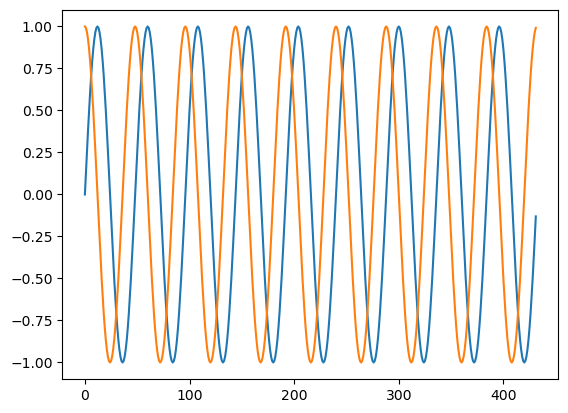

In [64]:
plt.plot(df_features['interval_sin'][(df_features['month_cos'] >= -0.5) & (df_features['Day'] < 10)])
plt.plot(df_features['interval_cos'][(df_features['month_cos'] >= -0.5) & (df_features['Day'] < 10)])
plt.show()

In [65]:
X = df_features.drop(columns=['Service Level', 'Call Volume', 'CCT', 'Abandoned Calls', 'Abandoned Rate'])
y = df_features['Call Volume']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import r2_score

model = LinearRegression().fit(X_train, y_train)

In [68]:
y_pred = model.predict(X_test)

print(f"R^2: {r2_score(y_pred=y_pred, y_true=y_test)}")
print(f"RMSE: {rmse(y_pred=y_pred, y_true=y_test)}")

R^2: 0.8168315661317836
RMSE: 38.24647148310238


In [69]:
df_features['Call Volume'].describe()

count    4368.000000
mean       80.759615
std        89.505319
min       -20.000000
25%         4.000000
50%        36.000000
75%       160.000000
max       335.000000
Name: Call Volume, dtype: float64

In [70]:
resid = y_test - y_pred

In [71]:
resid.describe()

count    874.000000
mean      -0.786313
std       38.260282
min     -100.305489
25%      -30.244517
50%       -0.884461
75%       23.910603
max      109.590478
Name: Call Volume, dtype: float64

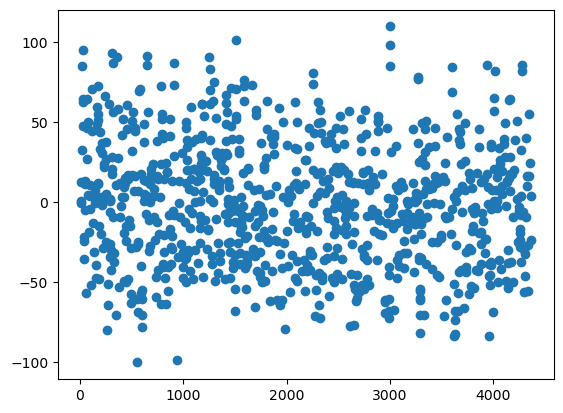

In [72]:
plt.scatter(X_test.index, resid)
plt.show()

## Daily

In [134]:
df_daily = pd.read_csv('./data/A - Daily.csv', index_col=0)

df_daily['Month'] = df_daily['Date'].apply(lambda x: int(x.split('/')[0]))
df_daily['Day'] = df_daily['Date'].apply(lambda x: int(x.split('/')[1]))
df_daily['Year'] = df_daily['Date'].apply(lambda x: int('20' + x.split('/')[2].split(' ')[0]))
df_daily['DayOfWeek'] = df_daily['Date'].apply(lambda x: x.split('/')[2].split(' ')[1])
df_daily.index = pd.to_datetime(list(df_daily['Date']))
df_daily = df_daily.drop(columns=['Date'])
us_holidays = holidays.US(years=[2024, 2025, 2026])
df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)
df_daily['Call Volume'] = df_daily['Call Volume'].interpolate(method='linear').astype(int)
df_daily['Service Level'] = df_daily['Service Level'].interpolate(method='linear')
df_daily['Abandon Rate'] = df_daily['Abandon Rate'].interpolate(method='linear')
df_daily['CCT'] = df_daily['CCT'].interpolate(method='linear')
df_daily.head()

/tmp/ipykernel_311624/3152512362.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_daily.index = pd.to_datetime(list(df_daily['Date']))
/tmp/ipykernel_311624/3152512362.py:10: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_daily['isHoliday']  = df_daily.index.isin(us_holidays).astype(int)


,Call Volume,CCT,Service Level,Abandon Rate,Month,Day,Year,DayOfWeek,isHoliday
2024-01-01,2147,302.4500,0.9855,0.0037,1,1,2024,Mon,1
2024-01-02,7458,349.2200,0.5213,0.1136,1,2,2024,Tue,0
2024-01-03,6882,331.0700,0.7046,0.0432,1,3,2024,Wed,0
2024-01-04,6208,341.8000,0.7200,0.0403,1,4,2024,Thu,0
2024-01-05,6190,334.5600,0.8063,0.0291,1,5,2024,Fri,0



--- Analysis for Call Volume ---
Durbin-Watson Statistic: 0.1726
Ljung-Box p-value (lag 10): 0.0000
Conclusion: Evidence of dependency (NOT independent).


<Figure size 1000x400 with 0 Axes>

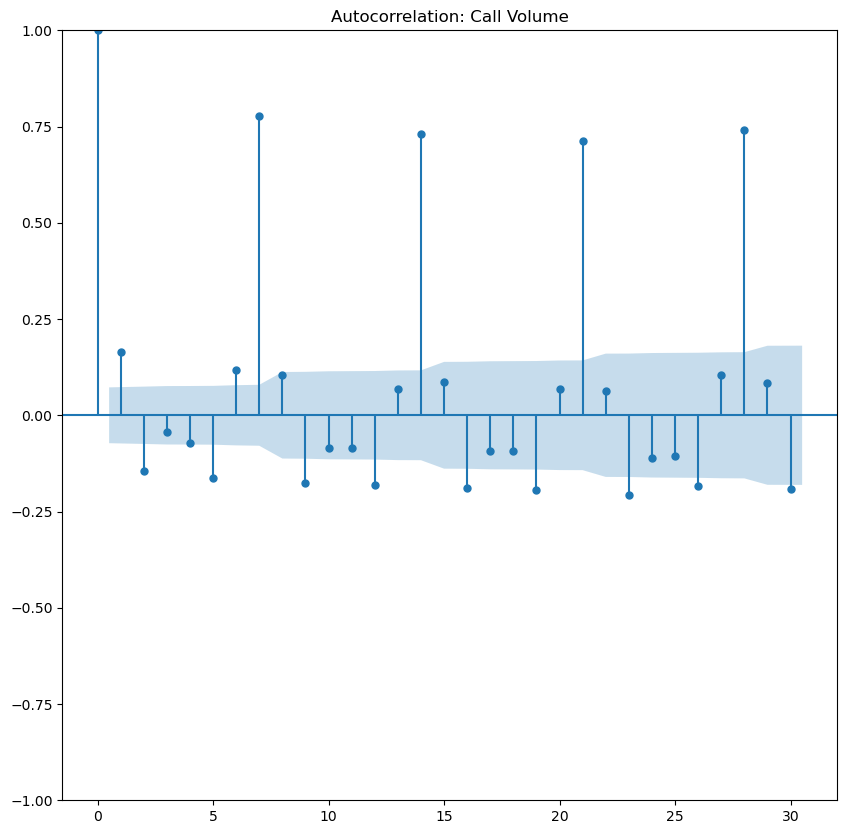


--- Analysis for CCT ---
Durbin-Watson Statistic: 0.0038
Ljung-Box p-value (lag 10): 0.0000
Conclusion: Evidence of dependency (NOT independent).


<Figure size 1000x400 with 0 Axes>

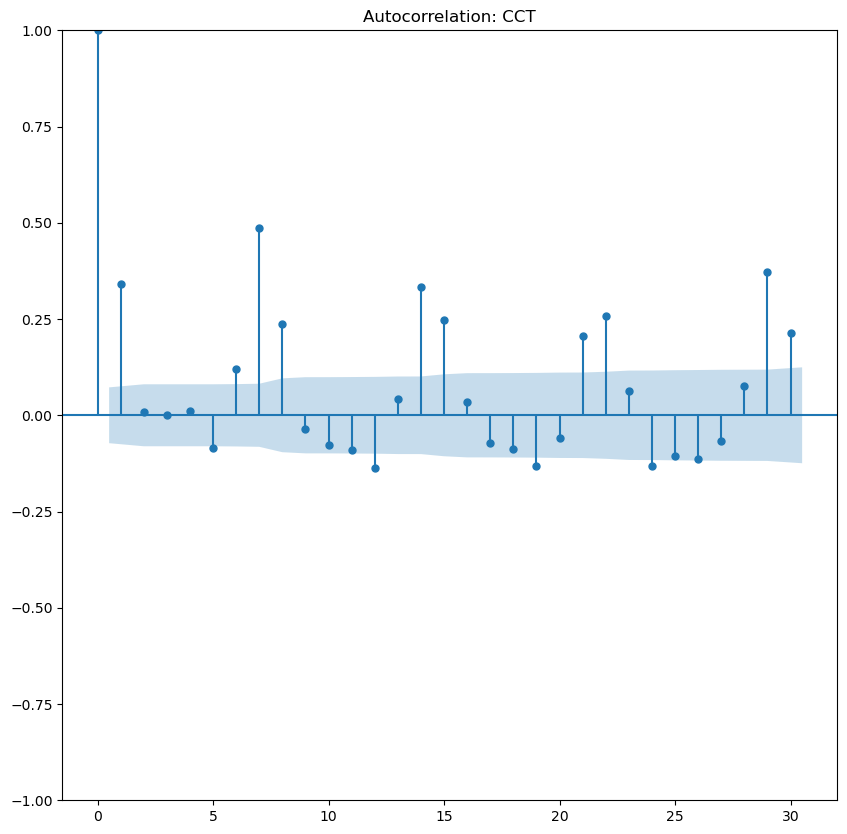


--- Analysis for Abandon Rate ---
Durbin-Watson Statistic: 0.5863
Ljung-Box p-value (lag 10): 0.0000
Conclusion: Evidence of dependency (NOT independent).


<Figure size 1000x400 with 0 Axes>

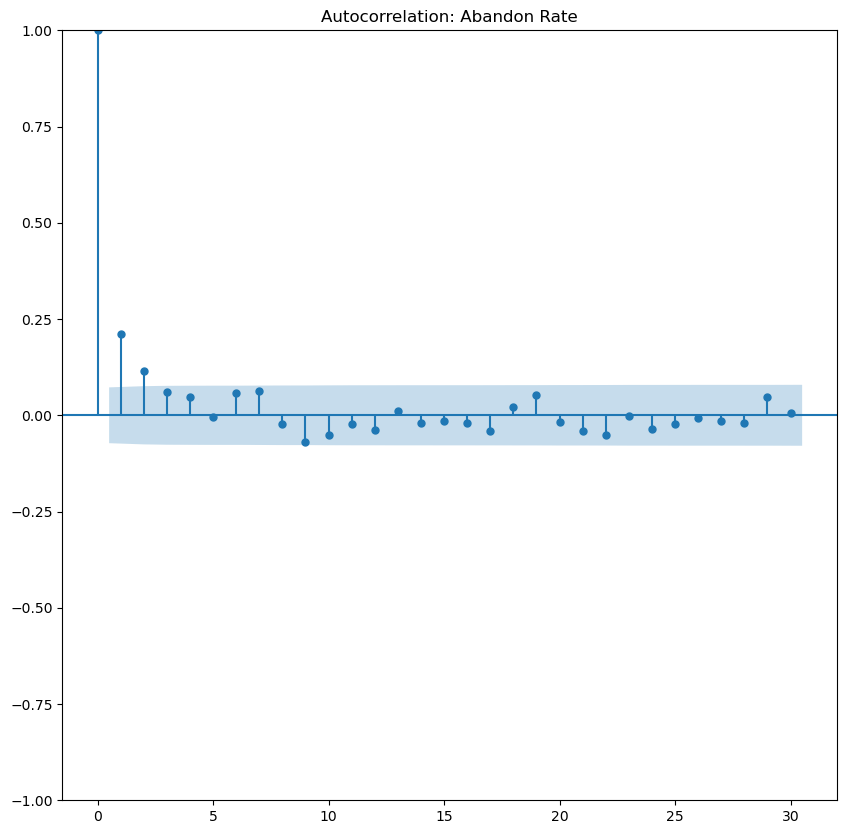


--- Analysis for Service Level ---
Durbin-Watson Statistic: 0.0036
Ljung-Box p-value (lag 10): 0.0000
Conclusion: Evidence of dependency (NOT independent).


<Figure size 1000x400 with 0 Axes>

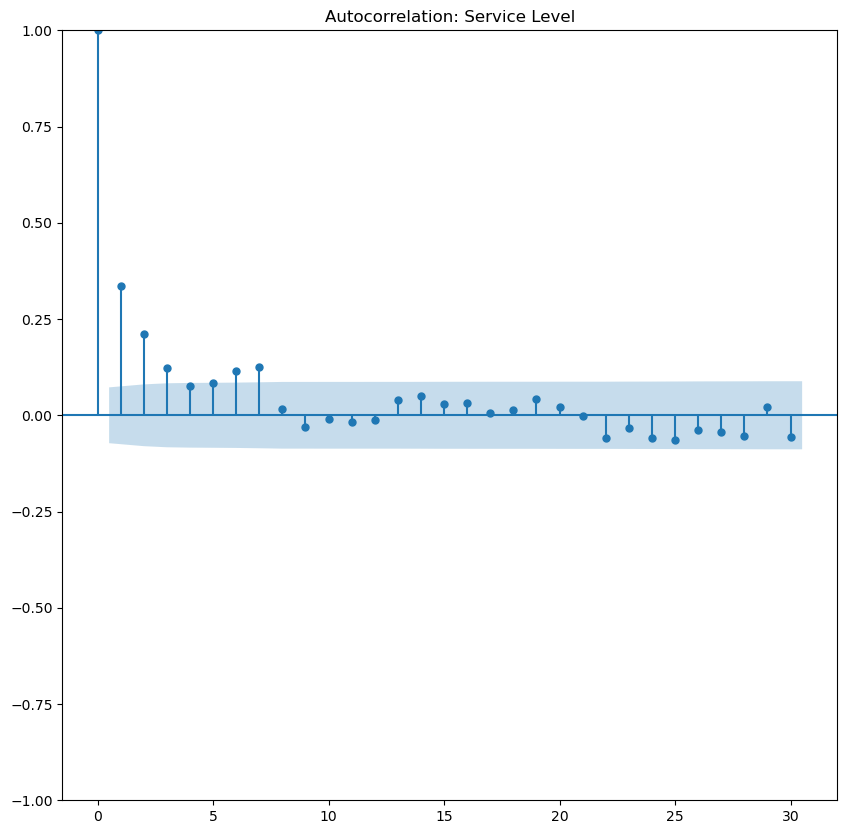

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# 1. Load your data


# Mock data generation to match your description
dates = pd.date_range(start='2024-01-01', end='2025-12-31', freq='D')
data = {
    'Date': [d.strftime('%m/%d/%Y %A') for d in dates],
    'Metric_1': np.random.normal(0, 1, len(dates)), # Random (Independent)
    'Metric_2': np.cumsum(np.random.normal(0, 1, len(dates))), # Trend (Dependent)
    'Metric_3': [np.sin(i/7) + np.random.normal(0, 0.2) for i in range(len(dates))], # Seasonal
    'Metric_4': np.random.poisson(5, len(dates)) # Discrete Random
}
df = pd.DataFrame(data)
df = df_daily.copy()

# 2. Preprocessing
# Extract just the MM/DD/YYYY part and convert to datetime
#df['Date'] = pd.to_datetime(df['Date'].str.split(' ').str[0])
#df.set_index('Date', inplace=True)

metrics = ['Call Volume', 'CCT', 'Abandon Rate', 'Service Level']

# 3. Analysis Loop
for col in metrics:
    print(f"\n--- Analysis for {col} ---")
    
    # Drop NaNs for the test (statsmodels requires contiguous/non-null data)
    series = df[col].dropna()
    
    # A. Durbin-Watson Test
    # Range is 0-4. Near 2.0 = No Autocorrelation (Independent)
    dw_stat = durbin_watson(series)
    print(f"Durbin-Watson Statistic: {dw_stat:.4f}")
    
    # B. Ljung-Box Test
    # Null Hypothesis (H0): The data is independently distributed (white noise)
    # If p-value < 0.05: Reject H0 -> Data is NOT independent
    lb_results = acorr_ljungbox(series, lags=[10], return_df=True)
    p_val = lb_results['lb_pvalue'].values[0]
    print(f"Ljung-Box p-value (lag 10): {p_val:.4f}")
    
    if p_val < 0.05:
        print("Conclusion: Evidence of dependency (NOT independent).")
    else:
        print("Conclusion: No significant evidence of dependency (Likely independent).")

    # C. ACF Plot
    plt.figure(figsize=(10, 4))
    plot_acf(series, lags=30, title=f"Autocorrelation: {col}")
    plt.show()

In [114]:
df_daily.head()

,Call Volume,CCT,Service Level,Abandon Rate,Month,Day,Year,DayOfWeek,isHoliday
2024-01-01,2147,302.4500,0.9855,0.0037,1,1,2024,Mon,1
2024-01-02,7458,349.2200,0.5213,0.1136,1,2,2024,Tue,0
2024-01-03,6882,331.0700,0.7046,0.0432,1,3,2024,Wed,0
2024-01-04,6208,341.8000,0.7200,0.0403,1,4,2024,Thu,0
2024-01-05,6190,334.5600,0.8063,0.0291,1,5,2024,Fri,0


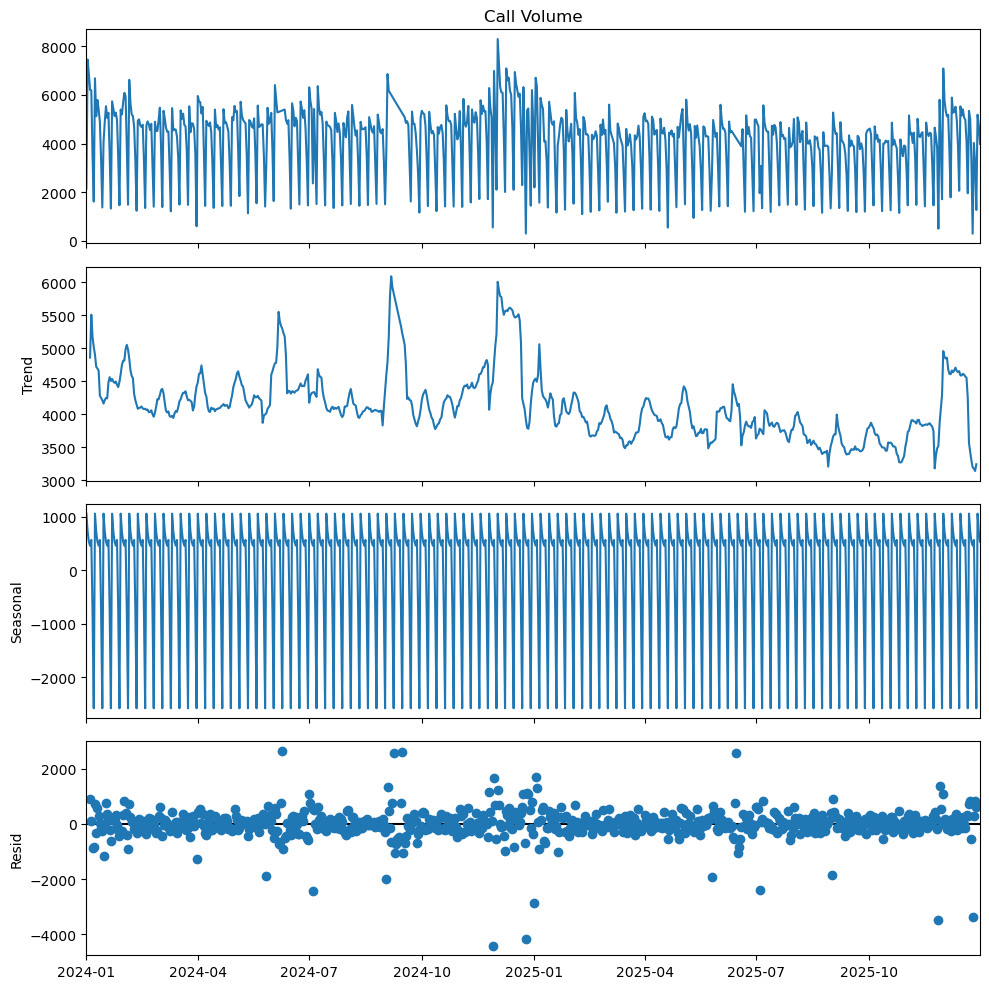

In [115]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_tsd = df_daily['Call Volume']
result = seasonal_decompose(df_tsd, model='additive', period=7)

# 4. Plot the components
plt.rcParams.update({'figure.figsize': (10,10)})
result.plot()
plt.show()

In [117]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Manual Lags
def create_lagged_features(df, target_cols, lag_days=[1, 7]):
    df_lagged = df.copy()
    
    # Create lags for ALL 4 metrics (even the one you aren't predicting)
    for col in target_cols:
        for lag in lag_days:
            df_lagged[f'{col}_lag{lag}'] = df[col].shift(lag)
            
    # Drop rows where lags are NaN (the first year of data)
    return df_lagged.dropna()

# Assuming 'df' has your 4 metrics and your DayOfWeek/Month features
# targets = ['Metric_1', 'Metric_2', 'Metric_3']
df_features = create_lagged_features(pd.get_dummies(df_daily, columns=['DayOfWeek'], prefix='DW'), ['Call Volume', 'CCT', 'Abandon Rate', 'Service Level'])

# 2. Split into X (Inputs) and Y (3 Targets)
X = df_features.drop(columns=['Call Volume', 'CCT', 'Abandon Rate'])
Y = df_features[['Call Volume', 'CCT', 'Abandon Rate']]

X_train, X_test = X[X.index < datetime()]

# 3. Multi-Output Model
# We use Random Forest because it handles the non-linear "shocks" in your residuals well
base_model = RandomForestRegressor(n_estimators=100, random_state=42)
mimo_model = MultiOutputRegressor(base_model)

mimo_model.fit(X, Y)

TypeError: 'module' object is not callable. Did you mean: 'datetime.datetime(...)'?

In [118]:
import pandas as pd
import numpy as np

# 1. Create the 2026 Date Range
test_dates = pd.date_range(start='2026-01-01', end='2026-08-31', freq='D')
test_df = pd.DataFrame(index=test_dates)

# 2. Extract Time Features
test_df['Month'] = test_df.index.month
test_df['Day'] = test_df.index.day
test_df['Year'] = test_df.index.year
test_df['DayOfWeek'] = test_df.index.day_name()

# 3. Dummify Day of Week
# Ensure these match the exact column names in your training set
test_df = pd.get_dummies(test_df, columns=['DayOfWeek'], prefix='DW')

# 4. Map the 365-Day Lags from your 2025 Historical Data
# Assume 'df_daily' is your original data from 2024-2025
# We look back exactly one year for each row in the test set

# 5. Handling the 'Short' Lags (The Gap Problem)
# Since you are forecasting 8 months out, you don't have Metric_lag1 or lag7 
# for August 2026 yet. Most people use the 'Last Known Value' from Dec 31, 2025 
# or a rolling average to fill these for long-horizon tests.
last_value_m1 = df_daily['Call Volume'].iloc[-1]
test_df['Call Volume_lag1'] = last_value_m1 
test_df['Call Volume_lag7'] = last_value_m1 
# ... repeat for other metrics ...
last_value_m1 = df_daily['CCT'].iloc[-1]
test_df['CCT_lag1'] = last_value_m1 
test_df['CCT_lag7'] = last_value_m1 

last_value_m1 = df_daily['Service Level'].iloc[-1]
test_df['Service Level_lag1'] = last_value_m1 
test_df['Service Level_lag7'] = last_value_m1 

last_value_m1 = df_daily['Abandon Rate'].iloc[-1]
test_df['Abandon Rate_lag1'] = last_value_m1 
test_df['Abandon Rate_lag7'] = last_value_m1 

print(test_df.head())

            Month  Day  Year  DW_Friday  DW_Monday  DW_Saturday  DW_Sunday  \
2026-01-01      1    1  2026      False      False        False      False   
2026-01-02      1    2  2026       True      False        False      False   
2026-01-03      1    3  2026      False      False         True      False   
2026-01-04      1    4  2026      False      False        False       True   
2026-01-05      1    5  2026      False       True        False      False   

            DW_Thursday  DW_Tuesday  DW_Wednesday  Call Volume_lag1  \
2026-01-01         True       False         False              3991   
2026-01-02        False       False         False              3991   
2026-01-03        False       False         False              3991   
2026-01-04        False       False         False              3991   
2026-01-05        False       False         False              3991   

            Call Volume_lag7  CCT_lag1  CCT_lag7  Service Level_lag1  \
2026-01-01              3991  33

In [119]:
test_df.head()

,Month,Day,Year,DW_Friday,DW_Monday,DW_Saturday,DW_Sunday,DW_Thursday,DW_Tuesday,DW_Wednesday,Call Volume_lag1,Call Volume_lag7,CCT_lag1,CCT_lag7,Service Level_lag1,Service Level_lag7,Abandon Rate_lag1,Abandon Rate_lag7
2026-01-01,1,1,2026,False,False,False,False,True,False,False,3991,3991,333.3100,333.3100,0.7732,0.7732,0.0236,0.0236
2026-01-02,1,2,2026,True,False,False,False,False,False,False,3991,3991,333.3100,333.3100,0.7732,0.7732,0.0236,0.0236
2026-01-03,1,3,2026,False,False,True,False,False,False,False,3991,3991,333.3100,333.3100,0.7732,0.7732,0.0236,0.0236
2026-01-04,1,4,2026,False,False,False,True,False,False,False,3991,3991,333.3100,333.3100,0.7732,0.7732,0.0236,0.0236
2026-01-05,1,5,2026,False,True,False,False,False,False,False,3991,3991,333.3100,333.3100,0.7732,0.7732,0.0236,0.0236


In [120]:
df_features.head()

,Call Volume,CCT,Service Level,Abandon Rate,Month,Day,Year,isHoliday,DW_Fri,DW_Mon,...,DW_Tue,DW_Wed,Call Volume_lag1,Call Volume_lag7,CCT_lag1,CCT_lag7,Abandon Rate_lag1,Abandon Rate_lag7,Service Level_lag1,Service Level_lag7
2024-01-08,6688,343.7500,0.8036,0.0173,1,8,2024,0,False,True,...,False,False,1611.0000,2147.0000,269.3200,302.4500,0.0056,0.0037,0.9707,0.9855
2024-01-09,5126,334.9400,0.9122,0.0090,1,9,2024,0,False,False,...,True,False,6688.0000,7458.0000,343.7500,349.2200,0.0173,0.1136,0.8036,0.5213
2024-01-10,5793,340.5600,0.8879,0.0097,1,10,2024,0,False,False,...,False,True,5126.0000,6882.0000,334.9400,331.0700,0.0090,0.0432,0.9122,0.7046
2024-01-11,5408,324.2200,0.9274,0.0089,1,11,2024,0,False,False,...,False,False,5793.0000,6208.0000,340.5600,341.8000,0.0097,0.0403,0.8879,0.7200
2024-01-12,4902,333.5000,0.9630,0.0065,1,12,2024,0,True,False,...,False,False,5408.0000,6190.0000,324.2200,334.5600,0.0089,0.0291,0.9274,0.8063


In [121]:
df_daily.head()

,Call Volume,CCT,Service Level,Abandon Rate,Month,Day,Year,DayOfWeek,isHoliday
2024-01-01,2147,302.4500,0.9855,0.0037,1,1,2024,Mon,1
2024-01-02,7458,349.2200,0.5213,0.1136,1,2,2024,Tue,0
2024-01-03,6882,331.0700,0.7046,0.0432,1,3,2024,Wed,0
2024-01-04,6208,341.8000,0.7200,0.0403,1,4,2024,Thu,0
2024-01-05,6190,334.5600,0.8063,0.0291,1,5,2024,Fri,0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# ==========================================
# 1. DATA PREPARATION (Full 2 Years)
# ==========================================

df = df_daily.copy()
# Assuming df contains: Call Volume, CCT, Service Level, Abandon Rate, Month, Day, Year, DayOfWeek, isHoliday, A
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# Clean Data (Prevent NaN loss)
df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()

# Dummify Day of Week
df = pd.get_dummies(df, columns=['DayOfWeek'], drop_first=False)

# Define Targets and Features
targets = ['Call Volume', 'CCT', 'Service Level', 'Abandon Rate']
features = [col for col in df.columns if col not in targets]

# Reorder dataframe
df = df[targets + features]
num_targets = len(targets)

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def create_sequences(data, time_steps, num_targets):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i : (i + time_steps), :])
        y.append(data[i + time_steps, :num_targets])
    return np.array(X), np.array(y)

def build_lstm_model(input_shape, num_targets):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    # Switch to 'tanh' or 'elu' for internal layers to prevent dying nodes
    model.add(LSTM(64, activation='tanh', return_sequences=True))
    model.add(Dropout(0.2))
    
    model.add(LSTM(32, activation='tanh', return_sequences=False))
    model.add(Dropout(0.2))
    
    # THE FIX: Force the output to stay strictly between 0 and 1 (matching the MinMaxScaler)
    model.add(Dense(num_targets, activation='sigmoid'))
    
    custom_adam = Adam(learning_rate=0.001, clipvalue=1.0)
    model.compile(optimizer=custom_adam, loss='mean_squared_error')
    
    return model

# ==========================================
# 3. TIME-SERIES CROSS VALIDATION
# ==========================================

time_steps = 14
test_size = 60 # 60 days per test fold
n_splits = 3
fold_metrics = []

for fold in range(n_splits):
    print(f"\n{'='*40}\nStarting Fold {fold + 1} of {n_splits}\n{'='*40}")
    K.clear_session() # Clear memory
    
    # Calculate splits (Working backward from Dec 31, 2025)
    test_end = len(df) - ((n_splits - 1 - fold) * test_size)
    test_start = test_end - test_size
    
    train_df = df.iloc[:test_start]
    test_df = df.iloc[test_start:test_end]
    
    print(f"Train bounds: {train_df.index[0].date()} to {train_df.index[-1].date()}")
    print(f"Test bounds:  {test_df.index[0].date()} to {test_df.index[-1].date()}")
    print(f"Training days: {len(train_df)}")
    
    # Scale Data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_train = scaler.fit_transform(train_df)
    scaled_test = scaler.transform(test_df)
    
    # Bridge the Lookback Gap
    test_input_data = np.vstack((scaled_train[-time_steps:], scaled_test))
    
    # Create Sequences
    X_train, y_train = create_sequences(scaled_train, time_steps, num_targets)
    X_test, y_test = create_sequences(test_input_data, time_steps, num_targets)
    
    # Train Model
    model = build_lstm_model((X_train.shape[1], X_train.shape[2]), num_targets)
    model.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0) 
    
    # Evaluate
    mse = model.evaluate(X_test, y_test, verbose=0)
    rmse = np.sqrt(mse)
    
    print(f"Fold {fold + 1} Scaled MSE:  {mse:.5f}")
    print(f"Fold {fold + 1} Scaled RMSE: {rmse:.5f}")
    
    fold_metrics.append(mse)

# ==========================================
# 4. FINAL RESULTS
# ==========================================
print(f"\n{'='*40}\nCross-Validation Complete\n{'='*40}")
avg_mse = np.mean(fold_metrics)
print(f"Average MSE:  {avg_mse:.5f}")
print(f"Average RMSE: {np.sqrt(avg_mse):.5f}")

/tmp/ipykernel_311624/3806654919.py:20: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()



Starting Fold 1 of 3
Train bounds: 2024-01-01 to 2025-07-04
Test bounds:  2025-07-05 to 2025-09-02
Training days: 551
Fold 1 Scaled MSE:  0.00951
Fold 1 Scaled RMSE: 0.09752

Starting Fold 2 of 3
Train bounds: 2024-01-01 to 2025-09-02
Test bounds:  2025-09-03 to 2025-11-01
Training days: 611
Fold 2 Scaled MSE:  0.01454
Fold 2 Scaled RMSE: 0.12059

Starting Fold 3 of 3
Train bounds: 2024-01-01 to 2025-11-01
Test bounds:  2025-11-02 to 2025-12-31
Training days: 671
Fold 3 Scaled MSE:  0.01712
Fold 3 Scaled RMSE: 0.13086

Cross-Validation Complete
Average MSE:  0.01373
Average RMSE: 0.11716


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ==========================================
# 1. TRAIN THE FINAL PRODUCTION MODEL
# ==========================================
# Assuming 'df' is your fully prepared, dummified dataset (Jan 2024 - Dec 2025)
# Make sure targets are the first 4 columns: ['Call Volume', 'CCT', 'Service Level', 'Abandoned Rate']

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_full_data = scaler.fit_transform(df)

time_steps = 14
num_targets = 4
total_features = df.shape[1]

# Create full sequences
X_full, y_full = create_sequences(scaled_full_data, time_steps, num_targets)

# Build and train the model on 100% of the data
prod_model = build_lstm_model((X_full.shape[1], X_full.shape[2]), num_targets)
print("Training final production model...")
prod_model.fit(X_full, y_full, epochs=40, batch_size=32, verbose=1)

# ==========================================
# 2. BUILD THE FUTURE DATAFRAME (Jan-Aug 2026)
# ==========================================
future_dates = pd.date_range(start='2026-01-01', end='2026-08-31', freq='D')
future_df = pd.DataFrame(index=future_dates)

# Initialize target columns with zeros
for target in targets:
    future_df[target] = 0.0

# Add known time features
future_df['Month'] = future_df.index.month
future_df['Day'] = future_df.index.day
future_df['Year'] = future_df.index.year
future_df['DayOfWeek'] = future_df.index.day_name()
future_df['isHoliday'] = 0 # Update this manually if you know 2026 holiday dates!

# Dummify DayOfWeek
future_df = pd.get_dummies(future_df, columns=['DayOfWeek'], drop_first=False)

# Ensure columns match perfectly (adds missing days as False)
for col in df.columns:
    if col not in future_df.columns:
        if 'DW_' in col: 
            future_df[col] = False
        else:
            future_df[col] = 0.0

future_df = future_df[df.columns] # Reorder to match training data exactly

# ==========================================
# 3. THE RECURSIVE FORECAST LOOP
# ==========================================
# Grab the last 14 days of Dec 2025 to prime the model
current_window = scaled_full_data[-time_steps:]
current_window = np.expand_dims(current_window, axis=0)

print("\nStarting recursive forecast to August 2026...")

for i in range(len(future_df)):
    # Predict the next day
    pred_scaled = prod_model.predict(current_window, verbose=0)
    
    # Un-scale the prediction
    dummy_row = np.zeros((1, total_features))
    dummy_row[0, :num_targets] = pred_scaled[0]
    real_pred = scaler.inverse_transform(dummy_row)[0, :num_targets]
    
    # Save into future_df
    future_df.iloc[i, 0:num_targets] = real_pred
    
    # Create the new row combining the prediction + known future features
    new_row_real = future_df.iloc[i].values.reshape(1, -1)
    new_row_scaled = scaler.transform(new_row_real)
    
    # Slide window forward
    current_window = np.append(current_window[:, 1:, :], [new_row_scaled], axis=1)

print("Forecast complete!")

pd.options.display.float_format = '{:.4f}'.format

print("\nAugust 2026 Forecast Preview:")
print(future_df.loc['2026-08-01':'2026-08-07', targets])

Training final production model...
Epoch 1/40


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0411
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0202
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0192
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0193
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0188
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0187
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0181
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0179
Epoch 9/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0175
Epoch 10/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0163
Epoch 11/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0154
Epoch 12/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0140
Epoch 13/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0132
Epoch 14/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0131
Epoch 15/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0130
Epoch 16/40
23/23 ━━━━━━━━━━━

/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/valida

Forecast complete!

August 2026 Forecast Preview:
            Call Volume      CCT  Service Level  Abandon Rate
2026-08-01    3308.7800 316.5212         0.9241        0.0145
2026-08-02    3428.5819 317.5365         0.9246        0.0145
2026-08-03    3503.2057 318.6110         0.9258        0.0142
2026-08-04    3537.7057 319.5197         0.9271        0.0139
2026-08-05    3537.0589 320.1966         0.9284        0.0136
2026-08-06    3508.5579 320.6421         0.9295        0.0134
2026-08-07    3460.3652 320.8845         0.9303        0.0132


/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


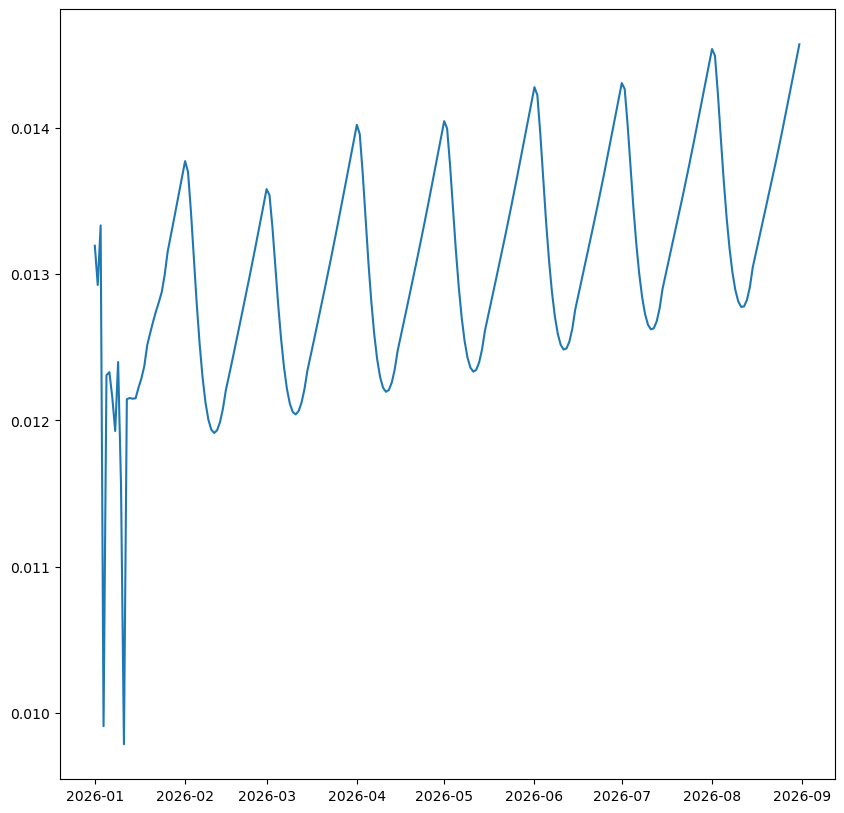

In [130]:
plt.plot(future_df['Abandon Rate'])
plt.show()

In [ ]:
import pandas as pd
import numpy as np

df_interval = pd.read_csv('./data/A - Interval.csv', index_col=0)


# 1. Define the start and end of the period
# April 1st, 2025 at 00:00 to June 30th, 2025 at 23:30
start = '2025-04-01 00:00:00'
end = '2025-06-30 23:30:00'

# 2. Generate the date range with 30-minute frequency
# 30min or 30T is the frequency for 30-minute increments
dr = pd.date_range(start=start, end=end, freq='30min')

# 3. Create the DataFrame and extract the requested columns
df = pd.DataFrame({'Timestamp': dr})

df_intervals = pd.DataFrame({
    'Month': df['Timestamp'].dt.month_name(),
    'Day': df['Timestamp'].dt.day,
    'Interval': df['Timestamp'].dt.strftime('%H:%M:%S'),
    'Day of the Week': df['Timestamp'].dt.day_name()
})

interval_df = df_intervals.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')
interval_df['Call Volume'] = interval_df['Call Volume'].interpolate(method='polynomial', order=2).astype(int)
interval_df['Service Level'] = interval_df['Service Level'].interpolate(method='polynomial', order=1)
interval_df['Abandoned Rate'] = interval_df['Abandoned Rate'].interpolate(method='linear')
interval_df['CCT'] = interval_df['CCT'].interpolate(method='polynomial', order=2)
mask = interval_df['Abandoned Calls'].isna()
interval_df.loc[mask, 'Abandoned Calls'] = (interval_df.loc[mask, 'Abandoned Rate'] * interval_df.loc[mask, 'Call Volume']).astype(int)

In [132]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CREATE THE WEIGHTED MASTER PROFILES
# ==========================================
# Assuming 'interval_df' is your April-June 2025 data
# Columns: Month, Day, Interval, Day of the Week, Service Level, Call Volume, Abandoned Rate, CCT

# A. Calculate the "Weighted Components" for each interval
# (Numerator for our weighted average: Rate * Volume)
interval_df['SL_Weight'] = interval_df['Service Level'] * interval_df['Call Volume']
interval_df['AR_Weight'] = interval_df['Abandoned Rate'] * interval_df['Call Volume']
interval_df['CCT_Weight'] = interval_df['CCT'] * interval_df['Call Volume']

# B. Roll up to find the True Daily Totals and Weighted Rates
# We group by Month and Day to isolate each specific date in the historical data
daily_actuals = interval_df.groupby(['Month', 'Day']).agg({
    'Call Volume': 'sum',
    'SL_Weight': 'sum',
    'AR_Weight': 'sum',
    'CCT_Weight': 'sum'
}).reset_index()

# C. Calculate the True Daily Weighted Average
# By dividing the sum of the weights by the total volume for the day
daily_actuals['Daily_Vol'] = daily_actuals['Call Volume']
# Using np.where to prevent division by zero just in case a day had literally 0 calls
daily_actuals['Daily_SL'] = np.where(daily_actuals['Daily_Vol'] == 0, 1.0, daily_actuals['SL_Weight'] / daily_actuals['Daily_Vol'])
daily_actuals['Daily_AR'] = np.where(daily_actuals['Daily_Vol'] == 0, 0.0, daily_actuals['AR_Weight'] / daily_actuals['Daily_Vol'])
daily_actuals['Daily_CCT'] = np.where(daily_actuals['Daily_Vol'] == 0, 0.0, daily_actuals['CCT_Weight'] / daily_actuals['Daily_Vol'])

# Drop the calculation columns, keep only the daily metrics
daily_actuals = daily_actuals[['Month', 'Day', 'Daily_Vol', 'Daily_SL', 'Daily_AR', 'Daily_CCT']]

# D. Merge back to the interval data to calculate Scaling Factors
interval_df = pd.merge(interval_df, daily_actuals, on=['Month', 'Day'])

# Volume uses a Percentage (Interval Vol / Daily Vol)
interval_df['Vol_Pct'] = np.where(interval_df['Daily_Vol'] == 0, 0, interval_df['Call Volume'] / interval_df['Daily_Vol'])

# Rates use a Scaling Factor (Interval Rate / Daily Rate)
interval_df['SL_Factor'] = np.where(interval_df['Daily_SL'] == 0, 1.0, interval_df['Service Level'] / interval_df['Daily_SL'])
interval_df['AR_Factor'] = np.where(interval_df['Daily_AR'] == 0, 1.0, interval_df['Abandoned Rate'] / interval_df['Daily_AR'])
interval_df['CCT_Factor'] = np.where(interval_df['Daily_CCT'] == 0, 1.0, interval_df['CCT'] / interval_df['Daily_CCT'])

# E. Build the MASTER PROFILE
# We average the factors across all Mondays, all Tuesdays, etc., for each specific time slot
master_profile = interval_df.groupby(['Day of the Week', 'Interval']).agg({
    'Vol_Pct': 'mean',
    'SL_Factor': 'mean',
    'AR_Factor': 'mean',
    'CCT_Factor': 'mean'
}).reset_index()

# ==========================================
# 2. APPLY TO AUGUST 2026 FORECAST
# ==========================================
# Assuming 'future_df' is your final LSTM output (Index is the Date)
future_df = future_df.reset_index()
future_df.rename(columns={'index': 'Date'}, inplace=True)
future_df['Date'] = pd.to_datetime(future_df['Date'])

# Create a master dataframe for every 30-minute block in August 2026
august_intervals = pd.date_range(start='2026-08-01 00:00:00', end='2026-08-31 23:30:00', freq='30min')
final_forecast = pd.DataFrame({'Date_Time': august_intervals})

# Extract components to match our Master Profile and LSTM predictions
final_forecast['Date'] = final_forecast['Date_Time'].dt.normalize() # Just the YYYY-MM-DD
final_forecast['Day of the Week'] = final_forecast['Date_Time'].dt.day_name()
# Format the time exactly as it appears in your snippet ('HH:MM:SS')
final_forecast['Interval'] = final_forecast['Date_Time'].dt.strftime('%H:%M:%S')

# A. Merge LSTM Daily Predictions onto the 30-min blocks
final_forecast = pd.merge(final_forecast, future_df[['Date', 'Call Volume', 'Service Level', 'Abandon Rate', 'CCT']], on='Date')

# B. Merge the Master Profiles
final_forecast = pd.merge(final_forecast, master_profile, on=['Day of the Week', 'Interval'], how='left')

# C. Calculate the Final Interval Predictions!
final_forecast['Pred_Interval_Volume'] = final_forecast['Call Volume'] * final_forecast['Vol_Pct']
final_forecast['Pred_Interval_SL'] = final_forecast['Service Level'] * final_forecast['SL_Factor']
final_forecast['Pred_Interval_AR'] = final_forecast['Abandon Rate'] * final_forecast['AR_Factor']
final_forecast['Pred_Interval_CCT'] = final_forecast['CCT'] * final_forecast['CCT_Factor']

# D. Final Safety Constraints
# Volume can't be a fraction of a call, so we round it
final_forecast['Pred_Interval_Volume'] = final_forecast['Pred_Interval_Volume'].round(0)

# Rates cannot mathematically exceed 100% or drop below 0%
final_forecast['Pred_Interval_SL'] = final_forecast['Pred_Interval_SL'].clip(lower=0.0, upper=1.0)
final_forecast['Pred_Interval_AR'] = final_forecast['Pred_Interval_AR'].clip(lower=0.0, upper=1.0)

# Clean up the dataframe for export
export_cols = ['Date_Time', 'Day of the Week', 'Interval', 'Pred_Interval_Volume', 'Pred_Interval_SL', 'Pred_Interval_AR', 'Pred_Interval_CCT']
final_forecast = final_forecast[export_cols]

print(final_forecast.head(10))

            Date_Time Day of the Week  Interval  Pred_Interval_Volume  \
0 2026-08-01 00:00:00        Saturday  00:00:00                7.0000   
1 2026-08-01 00:30:00        Saturday  00:30:00                5.0000   
2 2026-08-01 01:00:00        Saturday  01:00:00                4.0000   
3 2026-08-01 01:30:00        Saturday  01:30:00                2.0000   
4 2026-08-01 02:00:00        Saturday  02:00:00                2.0000   
5 2026-08-01 02:30:00        Saturday  02:30:00                2.0000   
6 2026-08-01 03:00:00        Saturday  03:00:00                2.0000   
7 2026-08-01 03:30:00        Saturday  03:30:00                2.0000   
8 2026-08-01 04:00:00        Saturday  04:00:00                2.0000   
9 2026-08-01 04:30:00        Saturday  04:30:00                1.0000   

   Pred_Interval_SL  Pred_Interval_AR  Pred_Interval_CCT  
0            0.9288            0.0694           377.5760  
1            0.9876            0.0000           406.3359  
2            0.9817

In [133]:
final_forecast.head()

,Date_Time,Day of the Week,Interval,Pred_Interval_Volume,Pred_Interval_SL,Pred_Interval_AR,Pred_Interval_CCT
0,2026-08-01 00:00:00,Saturday,00:00:00,7.0000,0.9288,0.0694,377.5760
1,2026-08-01 00:30:00,Saturday,00:30:00,5.0000,0.9876,0.0000,406.3359
2,2026-08-01 01:00:00,Saturday,01:00:00,4.0000,0.9817,0.0490,365.8347
3,2026-08-01 01:30:00,Saturday,01:30:00,2.0000,0.8877,0.1275,307.2750
4,2026-08-01 02:00:00,Saturday,02:00:00,2.0000,0.9289,0.1508,479.3212
